# I will examine the efficacy of random forest on the engineered dataset to predict team1 win or lose

In [2]:
import pandas as pd
df = pd.read_csv("../../data/rolling_feature_engineered_tier_1_games.csv")
df

,previous_10_game_team1_player1_average_kills,previous_10_game_team1_player1_average_deaths,previous_10_game_team1_player1_average_assists,previous_10_game_team1_player1_average_adr,previous_10_game_team1_player1_average_kast,previous_10_game_team1_player1_average_kddiff,previous_10_game_team1_player2_average_kills,previous_10_game_team1_player2_average_deaths,previous_10_game_team1_player2_average_assists,previous_10_game_team1_player2_average_adr,...,team1_player1_id,team1_player2_id,team1_player3_id,team1_player4_id,team1_player5_id,team2_player1_id,team2_player2_id,team2_player3_id,team2_player4_id,team2_player5_id
0,16.000000,15.000000,4.000000,75.000000,70.000000,1.000000,16.000000,15.000000,4.000000,75.000000,...,553.0,39.0,612.0,163.0,457.0,739.0,1443.0,65.0,2049.0,209.0
1,12.000000,17.000000,4.000000,59.100000,62.500000,-5.000000,13.000000,11.000000,2.000000,52.600000,...,553.0,39.0,612.0,163.0,457.0,739.0,1443.0,65.0,2049.0,209.0
2,13.500000,16.500000,4.500000,66.250000,71.750000,-3.000000,18.500000,11.000000,4.000000,82.550000,...,553.0,39.0,612.0,163.0,457.0,739.0,1443.0,65.0,2049.0,209.0
3,14.612903,14.645161,4.258065,69.832258,71.535484,-0.032258,14.612903,14.645161,4.258065,69.832258,...,3202.0,1420.0,3168.0,607.0,3032.0,3836.0,1886.0,2588.0,1778.0,4567.0
4,13.000000,5.000000,1.000000,81.300000,86.700000,8.000000,11.000000,6.000000,4.000000,72.100000,...,3202.0,1420.0,3168.0,607.0,3032.0,3836.0,1886.0,2588.0,1778.0,4567.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5534,15.400000,14.800000,4.900000,73.770000,77.820000,0.600000,14.200000,12.900000,3.900000,66.030000,...,2988.0,266.0,7528.0,6900.0,16113.0,1401.0,169.0,1834.0,2934.0,7201.0
5535,16.600000,15.500000,5.000000,76.570000,76.160000,1.100000,14.900000,13.400000,3.900000,66.480000,...,2988.0,266.0,7528.0,6900.0,16113.0,1401.0,169.0,1834.0,2934.0,7201.0
5536,15.400000,15.900000,4.600000,73.230000,73.160000,-0.500000,14.800000,13.600000,3.700000,66.540000,...,2988.0,266.0,7528.0,6900.0,16113.0,1401.0,169.0,1834.0,2934.0,7201.0
5537,13.300000,13.400000,4.500000,67.660000,73.790000,-0.100000,10.700000,13.700000,5.800000,57.120000,...,1401.0,169.0,1834.0,2934.0,7201.0,19.0,550.0,1549.0,1443.0,146.0


In [3]:
df.columns

Index(['previous_10_game_team1_player1_average_kills',
       'previous_10_game_team1_player1_average_deaths',
       'previous_10_game_team1_player1_average_assists',
       'previous_10_game_team1_player1_average_adr',
       'previous_10_game_team1_player1_average_kast',
       'previous_10_game_team1_player1_average_kddiff',
       'previous_10_game_team1_player2_average_kills',
       'previous_10_game_team1_player2_average_deaths',
       'previous_10_game_team1_player2_average_assists',
       'previous_10_game_team1_player2_average_adr',
       'previous_10_game_team1_player2_average_kast',
       'previous_10_game_team1_player2_average_kddiff',
       'previous_10_game_team1_player3_average_kills',
       'previous_10_game_team1_player3_average_deaths',
       'previous_10_game_team1_player3_average_assists',
       'previous_10_game_team1_player3_average_adr',
       'previous_10_game_team1_player3_average_kast',
       'previous_10_game_team1_player3_average_kddiff',
       

I'm going to drop arbitrary data like ids and names

In [4]:
to_drop = []
to_drop.extend([f"team{i}_player{k}_id" for i in range(1,3) for k in range(1,6)])
to_drop.extend([f"team{i}_id" for i in range(1,3)])
to_drop.extend([f"team{i}" for i in range(1,3)])
to_drop.extend(["tournament", "match_id", "game_id", "map_id", "map_name", "datetime"])
df = df.drop(to_drop, axis=1)
df

,previous_10_game_team1_player1_average_kills,previous_10_game_team1_player1_average_deaths,previous_10_game_team1_player1_average_assists,previous_10_game_team1_player1_average_adr,previous_10_game_team1_player1_average_kast,previous_10_game_team1_player1_average_kddiff,previous_10_game_team1_player2_average_kills,previous_10_game_team1_player2_average_deaths,previous_10_game_team1_player2_average_assists,previous_10_game_team1_player2_average_adr,...,previous_10_game_team2_player5_average_kills,previous_10_game_team2_player5_average_deaths,previous_10_game_team2_player5_average_assists,previous_10_game_team2_player5_average_adr,previous_10_game_team2_player5_average_kast,previous_10_game_team2_player5_average_kddiff,team1_win,bestOf,team1_previous_10_average_map_score,team2_previous_10_average_map_score
0,16.000000,15.000000,4.000000,75.000000,70.000000,1.000000,16.000000,15.000000,4.000000,75.000000,...,16.000000,15.000000,4.000000,75.000000,70.000000,1.000000,0,3.0,13.000000,13.000000
1,12.000000,17.000000,4.000000,59.100000,62.500000,-5.000000,13.000000,11.000000,2.000000,52.600000,...,13.000000,16.000000,4.000000,49.000000,58.300000,-3.000000,1,3.0,12.333333,12.333333
2,13.500000,16.500000,4.500000,66.250000,71.750000,-3.000000,18.500000,11.000000,4.000000,82.550000,...,11.000000,16.500000,5.000000,61.500000,60.100000,-5.500000,1,3.0,11.600000,11.600000
3,14.612903,14.645161,4.258065,69.832258,71.535484,-0.032258,14.612903,14.645161,4.258065,69.832258,...,14.612903,14.645161,4.258065,69.832258,71.535484,-0.032258,1,3.0,11.571429,11.571429
4,13.000000,5.000000,1.000000,81.300000,86.700000,8.000000,11.000000,6.000000,4.000000,72.100000,...,2.000000,14.000000,0.000000,23.500000,26.700000,-12.000000,1,3.0,10.666667,10.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5534,15.400000,14.800000,4.900000,73.770000,77.820000,0.600000,14.200000,12.900000,3.900000,66.030000,...,18.600000,15.800000,7.600000,93.320000,77.400000,2.800000,0,3.0,13.400000,9.500000
5535,16.600000,15.500000,5.000000,76.570000,76.160000,1.100000,14.900000,13.400000,3.900000,66.480000,...,19.100000,15.900000,6.800000,90.800000,76.820000,3.200000,0,3.0,9.700000,11.100000
5536,15.400000,15.900000,4.600000,73.230000,73.160000,-0.500000,14.800000,13.600000,3.700000,66.540000,...,19.900000,16.000000,6.700000,90.800000,75.820000,3.900000,1,3.0,11.000000,10.700000
5537,13.300000,13.400000,4.500000,67.660000,73.790000,-0.100000,10.700000,13.700000,5.800000,57.120000,...,16.600000,11.400000,4.500000,82.410000,82.000000,5.200000,0,5.0,11.400000,12.700000


In [5]:
df.columns

Index(['previous_10_game_team1_player1_average_kills',
       'previous_10_game_team1_player1_average_deaths',
       'previous_10_game_team1_player1_average_assists',
       'previous_10_game_team1_player1_average_adr',
       'previous_10_game_team1_player1_average_kast',
       'previous_10_game_team1_player1_average_kddiff',
       'previous_10_game_team1_player2_average_kills',
       'previous_10_game_team1_player2_average_deaths',
       'previous_10_game_team1_player2_average_assists',
       'previous_10_game_team1_player2_average_adr',
       'previous_10_game_team1_player2_average_kast',
       'previous_10_game_team1_player2_average_kddiff',
       'previous_10_game_team1_player3_average_kills',
       'previous_10_game_team1_player3_average_deaths',
       'previous_10_game_team1_player3_average_assists',
       'previous_10_game_team1_player3_average_adr',
       'previous_10_game_team1_player3_average_kast',
       'previous_10_game_team1_player3_average_kddiff',
       

Note that even after dropping that data, we still have a lot of dimensions to this data (63 features)

In [6]:
df.head(5)

,previous_10_game_team1_player1_average_kills,previous_10_game_team1_player1_average_deaths,previous_10_game_team1_player1_average_assists,previous_10_game_team1_player1_average_adr,previous_10_game_team1_player1_average_kast,previous_10_game_team1_player1_average_kddiff,previous_10_game_team1_player2_average_kills,previous_10_game_team1_player2_average_deaths,previous_10_game_team1_player2_average_assists,previous_10_game_team1_player2_average_adr,...,previous_10_game_team2_player5_average_kills,previous_10_game_team2_player5_average_deaths,previous_10_game_team2_player5_average_assists,previous_10_game_team2_player5_average_adr,previous_10_game_team2_player5_average_kast,previous_10_game_team2_player5_average_kddiff,team1_win,bestOf,team1_previous_10_average_map_score,team2_previous_10_average_map_score
0,16.000000,15.000000,4.000000,75.000000,70.000000,1.000000,16.000000,15.000000,4.000000,75.000000,...,16.000000,15.000000,4.000000,75.000000,70.000000,1.000000,0,3.0,13.000000,13.000000
1,12.000000,17.000000,4.000000,59.100000,62.500000,-5.000000,13.000000,11.000000,2.000000,52.600000,...,13.000000,16.000000,4.000000,49.000000,58.300000,-3.000000,1,3.0,12.333333,12.333333
2,13.500000,16.500000,4.500000,66.250000,71.750000,-3.000000,18.500000,11.000000,4.000000,82.550000,...,11.000000,16.500000,5.000000,61.500000,60.100000,-5.500000,1,3.0,11.600000,11.600000
3,14.612903,14.645161,4.258065,69.832258,71.535484,-0.032258,14.612903,14.645161,4.258065,69.832258,...,14.612903,14.645161,4.258065,69.832258,71.535484,-0.032258,1,3.0,11.571429,11.571429
4,13.000000,5.000000,1.000000,81.300000,86.700000,8.000000,11.000000,6.000000,4.000000,72.100000,...,2.000000,14.000000,0.000000,23.500000,26.700000,-12.000000,1,3.0,10.666667,10.666667


Now, let's do our train/test split and (no feature standardization required for random forest)

In [7]:
import math
split_point = math.ceil(len(df) * 0.8)
# SPLIT MUST BE TEMPORAL TO AVOID TEST LEAKAGE INTO TRAIN SINCE
# FEATURES ARE CUMULATIVE
train = df.iloc[:split_point] # 0 to split_point - 1
test = df.iloc[split_point:] # split_point to len(df)
X_train = train.drop("team1_win", axis=1)
y_train = train.team1_win
X_test = test.drop("team1_win", axis=1)
y_test = test.team1_win

In [8]:
display(X_train.head())
display(X_test.head())

,previous_10_game_team1_player1_average_kills,previous_10_game_team1_player1_average_deaths,previous_10_game_team1_player1_average_assists,previous_10_game_team1_player1_average_adr,previous_10_game_team1_player1_average_kast,previous_10_game_team1_player1_average_kddiff,previous_10_game_team1_player2_average_kills,previous_10_game_team1_player2_average_deaths,previous_10_game_team1_player2_average_assists,previous_10_game_team1_player2_average_adr,...,previous_10_game_team2_player4_average_kddiff,previous_10_game_team2_player5_average_kills,previous_10_game_team2_player5_average_deaths,previous_10_game_team2_player5_average_assists,previous_10_game_team2_player5_average_adr,previous_10_game_team2_player5_average_kast,previous_10_game_team2_player5_average_kddiff,bestOf,team1_previous_10_average_map_score,team2_previous_10_average_map_score
0,16.000000,15.000000,4.000000,75.000000,70.000000,1.000000,16.000000,15.000000,4.000000,75.000000,...,1.000000,16.000000,15.000000,4.000000,75.000000,70.000000,1.000000,3.0,13.000000,13.000000
1,12.000000,17.000000,4.000000,59.100000,62.500000,-5.000000,13.000000,11.000000,2.000000,52.600000,...,1.000000,13.000000,16.000000,4.000000,49.000000,58.300000,-3.000000,3.0,12.333333,12.333333
2,13.500000,16.500000,4.500000,66.250000,71.750000,-3.000000,18.500000,11.000000,4.000000,82.550000,...,-1.500000,11.000000,16.500000,5.000000,61.500000,60.100000,-5.500000,3.0,11.600000,11.600000
3,14.612903,14.645161,4.258065,69.832258,71.535484,-0.032258,14.612903,14.645161,4.258065,69.832258,...,-0.032258,14.612903,14.645161,4.258065,69.832258,71.535484,-0.032258,3.0,11.571429,11.571429
4,13.000000,5.000000,1.000000,81.300000,86.700000,8.000000,11.000000,6.000000,4.000000,72.100000,...,-11.000000,2.000000,14.000000,0.000000,23.500000,26.700000,-12.000000,3.0,10.666667,10.666667


,previous_10_game_team1_player1_average_kills,previous_10_game_team1_player1_average_deaths,previous_10_game_team1_player1_average_assists,previous_10_game_team1_player1_average_adr,previous_10_game_team1_player1_average_kast,previous_10_game_team1_player1_average_kddiff,previous_10_game_team1_player2_average_kills,previous_10_game_team1_player2_average_deaths,previous_10_game_team1_player2_average_assists,previous_10_game_team1_player2_average_adr,...,previous_10_game_team2_player4_average_kddiff,previous_10_game_team2_player5_average_kills,previous_10_game_team2_player5_average_deaths,previous_10_game_team2_player5_average_assists,previous_10_game_team2_player5_average_adr,previous_10_game_team2_player5_average_kast,previous_10_game_team2_player5_average_kddiff,bestOf,team1_previous_10_average_map_score,team2_previous_10_average_map_score
4432,16.8,13.6,5.1,82.56,72.14,3.2,11.2,13.9,7.3,59.02,...,-0.9,13.3,13.3,4.9,73.04,66.71,0.0,3.0,12.125,10.862267
4433,12.2,11.4,3.7,66.95,74.91,0.8,16.2,11.4,4.6,88.86,...,-0.9,14.0,14.6,5.5,73.15,72.89,-0.6,3.0,11.200,11.200000
4434,11.9,10.9,3.0,64.63,76.29,1.0,15.6,11.2,4.9,89.28,...,-1.3,13.2,14.2,5.4,71.59,72.68,-1.0,3.0,11.800,9.400000
4435,12.8,10.9,2.9,67.67,75.83,1.9,15.2,11.2,4.7,88.97,...,-0.8,13.2,13.8,5.7,71.94,72.22,-0.6,3.0,10.500,11.600000
4436,12.4,15.0,5.5,64.99,66.91,-2.6,13.9,15.7,3.6,71.59,...,-2.3,15.2,13.6,4.9,73.79,72.36,1.6,3.0,12.000,9.000000


Now we can train our random forest classifier

First, we'll want to do hyperparameter-tuning

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np
rfc = RandomForestClassifier(random_state=42)
grid = {"max_depth": np.arange(10, 201, 30), "n_estimators": np.arange(10, 201, 30)}
cv = GridSearchCV(rfc, param_grid=grid, n_jobs=-1, verbose=2)
cv.fit(X_train, y_train)

Fitting 5 folds for each of 49 candidates, totalling 245 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 10, ...30, 160, 190]), 'n_estimators': array([ 10, ...30, 160, 190])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 

We'll examine best score and params

In [10]:
cv.best_params_

{'max_depth': np.int64(10), 'n_estimators': np.int64(190)}

In [11]:
cv.best_score_

np.float64(0.562277288447884)

Now generate a heatmap for the scores

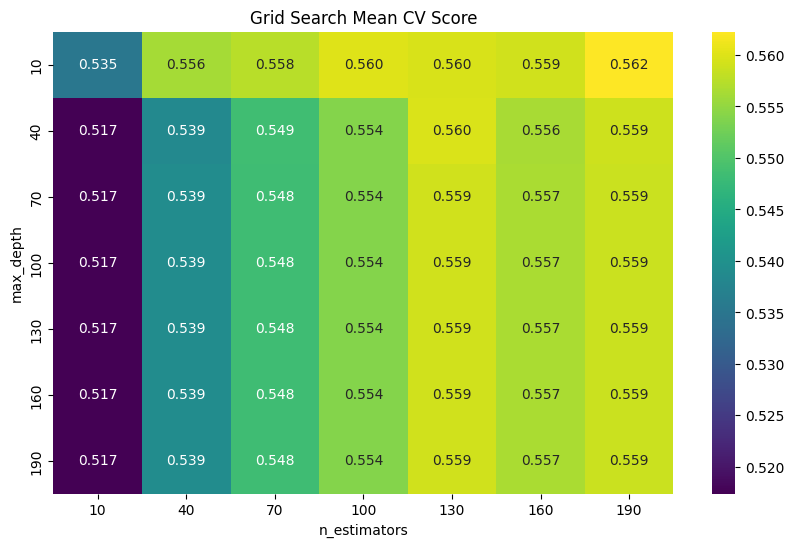

In [12]:
#ChatGPT generated
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt

results = pd.DataFrame(cv.cv_results_)
heatmap_data = results.pivot(
    index="param_max_depth",
    columns="param_n_estimators",
    values="mean_test_score"
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
plt.title("Grid Search Mean CV Score")
plt.xlabel("n_estimators")
plt.ylabel("max_depth")
plt.show()

So a lower depth with estimators from 130-190 is more ideal. Let's retry.

In [13]:
grid = {"max_depth": np.arange(1, 40, 5), "n_estimators": np.arange(130, 251, 20)}
cv = GridSearchCV(rfc, param_grid=grid, n_jobs=-1, verbose=2)
cv.fit(X_train, y_train)

Fitting 5 folds for each of 56 candidates, totalling 280 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 1, 6..., 26, 31, 36]), 'n_estimators': array([130, 1...10, 230, 250])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

Examine results again

In [14]:
cv.best_score_

np.float64(0.5683654798048562)

In [15]:
cv.best_params_

{'max_depth': np.int64(16), 'n_estimators': np.int64(250)}

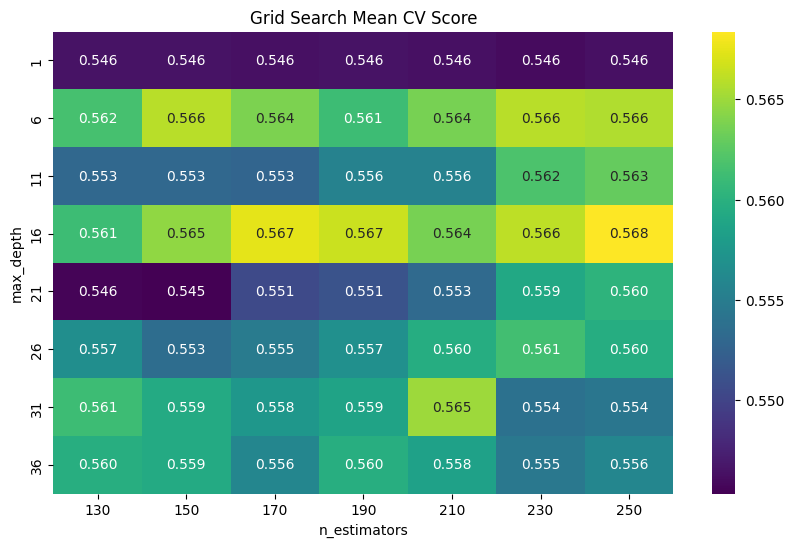

In [16]:
#ChatGPT generated
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt

results = pd.DataFrame(cv.cv_results_)
heatmap_data = results.pivot(
    index="param_max_depth",
    columns="param_n_estimators",
    values="mean_test_score"
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
plt.title("Grid Search Mean CV Score")
plt.xlabel("n_estimators")
plt.ylabel("max_depth")
plt.show()

The structure is much less defined with this one, with good scores occuring around islands in a sea of lower scores, at higher depths, but we see a general trend of higher scores at depth 16 on the edge of 250. More estimators might help, but we will stop here.

Let's see how it assigned feature importance.

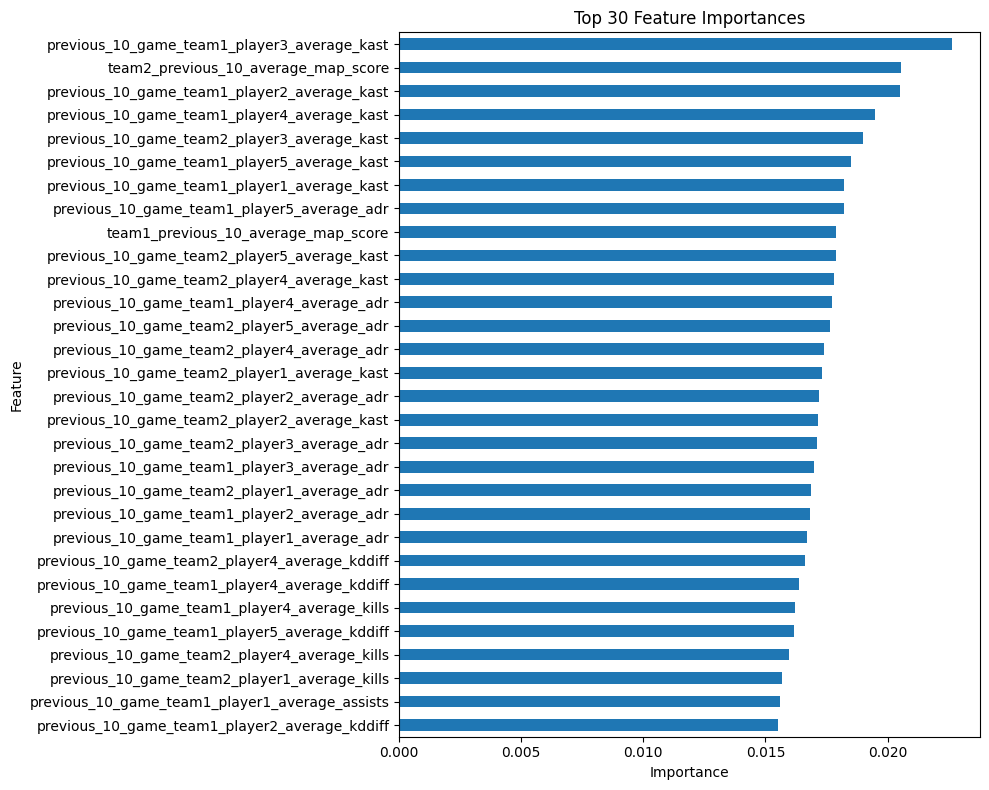

In [17]:
#ChatGPT generated
import pandas as pd

import matplotlib.pyplot as plt

feature_importances = pd.Series(
    cv.best_estimator_.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top30 = feature_importances.head(30).sort_values()

plt.figure(figsize=(10, 8))
top30.plot(kind="barh")
plt.title("Top 30 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

It can't really seem to figure out which features are important with feature importances decreasing very slowly from one to the next, meaning the model is unsure of which feature explains the variance in the target, so it uses many features in its prediction.

In [18]:
cv.best_estimator_.score(X_test, y_test)

0.5672990063233966

It does about 1% better than baseline on the test set.